# Running PATH on Simulated FRBs

This notebook demonstrates how to run PATH (Probabilistic Association of Transients to Hosts) on FRB host association scenarios simulated using `astropath.simulations.generate_frbs` and `astropath.simulations.assign_host`.

The workflow consists of three main steps:
1. **Generate FRBs**: Simulate the population of FRBs (DMs, redshifts) and corresponding host galaxies (absolute and apparent magnitudes) that we expect to detect for different FRB surveys (see the `Simulate_Generate_FRBs.ipynb` notebook for more details)
2. **Assign to Hosts**: Use wide-field catalogs to place FRBs in host galaxies on-sky according to their simulated apparent magnitude. FRBs are also randomly placed *within* their host galaxy according to an intrinsic galactocentric offset distribution and a localization region. (see the `Simulate_Assign_FRBs.ipynb` notebook for more details)
3. **Run PATH**: Run PATH on all simulated scenarios, parallelized over multiple cores.
4. **Build Digest**: Combines together the `pandas.DataFrame` from each step into a "digest" `DataFrame` that can be easily parsed to make informative plots about the simulations. This digest contains the following columns:
- `ra_loc`: Observed FRB RA (degrees) - includes localization error
- `dec_loc`: Observed FRB Dec (degrees) - includes localization error
- `true_ra`: True FRB RA in the galaxy (degrees)
- `true_dec`: True FRB Dec in the galaxy (degrees)
- `host_ID`: ID of assigned host galaxy within the possible host catalog (see `assign_host` step)
- `gal_off`: Offset from galaxy center (arcsec)
- `mag_host`: Apparent r-band magnitude of the true host galaxy
- `ang_size_host`: Angular size of the true host galaxy (arcsec)
- `loc_off`: Localization error offset (arcsec)
- `FRB_ID`: FRB index from the `generate_frbs` step
- `a`: Localization semi-major axis (arcsec)
- `b`: Localization semi-minor axis (arcsec)
- `PA`: Localization position angle (degrees)
- `ra_host`: RA of the host galaxy center (degrees)
- `dec_host`: DEC of the host galaxy center (degrees)
- `sep_best_host_arcsec`: Separation between the center of the best candidate and true host (arcsec)
- `sep_host_loc_arcsec`: Separation between the center of the true host and localization (arcsec)
- `sep_best_loc_arcsec`: Separation between the center of the best candidate and localization (arcsec)
- `sep_host_loc_norm`: Separation between the center of the true host and localization, normalized by the angular size of the true host
- `sep_best_loc_norm`: Separation between the center of the best candidate and localization, normalized by the angular size of the best candidate
- `z_host`: Simulated FRB redshift
- `dmex_host`: Simulated FRB extragalactic DM
- `frb_mr`: Simulated FRB host apparent r-band magnitude
- `frb_Mr`: Simulated FRB host absolute r-band magnitude
- `ra_cand`: RA of the best candidate galaxy center (degrees)
- `dec_cand`: DEC of the best candidate galaxy center (degrees)
- `mag_cand`: Apparent r-band magnitude of the best candidate galaxy
- `ang_size_cand`: Angular size of the best candidate galaxy (arcsec)
- `cand_ID`: ID of assigned host galaxy within the galaxy catalog used to run PATH (see `run_path` step)
- `P_O`: Value of the PATH prior P(Oi) for the best candidate
- `p_xO`: Value of the PATH likelihood p(x|Oi) for the best candidate
- `P_Ox`: Value of the PATH posterior P(Oi|x) for the best candidate
- `P_Ux`: Value of the PATH posterior P(U|x)
- `correct_association`: A boolean indicating whether the best candidate matches the true host (a "correct" association), based on a spatial cross-match


In [1]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('text', usetex=False)
import matplotlib

import os
import numpy as np
from importlib import reload
import pandas as pd
from pathlib import Path

from astropy.table import Table
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units
from importlib.resources import files
import time
import random

In [2]:
# Import astropath modules
from astropath.simulations import generate_frbs, assign_frbs_to_hosts, load_galaxy_catalog, run_path
from astropath.simulations import utils as sim_utils
from astropath import run

If you wish to use the halos modules, you need the Aemulus HMF emulator. Please install it: github.com/AemulusProject/hmf_emulator
If you wish to use the halos modules, you need the Aemulus HMF emulator. Please install it: github.com/AemulusProject/hmf_emulator


## Step 1: Generate FRB Population

First, we generate a population of FRBs using `generate_frbs()`. This gives us FRBs with realistic DM, redshift, and host galaxy magnitude distributions for different surveys. See the `Simulate_Generate_FRBs.ipynb` notebook and Section 3.1 of Andersen+26 for more details.

In [3]:
# Generate CHIME FRBs following the Catalog 1 DM distribution with S/N > 12
n_frbs = 1000
seed = 42

fn = files('astropath.data') / 'frb_surveys' / 'chimefrbcat1.csv'
df_dr1 = pd.read_csv(fn)
chime_dms_eg = np.nanmean([df_dr1['dm_exc_ne2001'].values,df_dr1['dm_exc_ymw16'].values], axis=0)
chime_snrs = df_dr1['bonsai_snr']
threshold = 12.
chime_observed_dms_eg = chime_dms_eg[chime_snrs > threshold]

# See the `Simulate_Generate_FRBs.ipynb` notebook for a summary of this module
frbs = generate_frbs(n_frbs, 'CHIME', seed=seed, 
        dm_catalog=chime_observed_dms_eg)

print(f"Generated {len(frbs)} FRBs")
print(f"\nFRB properties:")
print(f"  DM range:  {frbs['DMeg'].min():.0f} - {frbs['DMeg'].max():.0f} pc/cm³")
print(f"  z range:   {frbs['z'].min():.3f} - {frbs['z'].max():.3f}")
print(f"  M_r range: {frbs['M_r'].min():.2f} - {frbs['M_r'].max():.2f}")
print(f"  m_r range: {frbs['m_r'].min():.2f} - {frbs['m_r'].max():.2f}")

frbs

Loading P(DM,z) grid from /Users/bandersen/miniforge3/envs/frbs2/lib/python3.11/site-packages/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Using Lz values to sample host galaxy absolute magnitudes
Generated 1000 FRBs

FRB properties:
  DM range:  4 - 2238 pc/cm³
  z range:   0.010 - 2.135
  M_r range: -24.50 - -15.48
  m_r range: 10.94 - 28.62


,DMeg,z,M_r,m_r
0,332.858066,0.129937,-21.388885,17.609148
1,1310.849406,1.151786,-21.443314,23.094695
2,701.321672,0.890507,-18.183908,25.665941
3,535.564011,0.598077,-21.433778,21.360838
4,166.115017,0.195489,-21.351292,18.620048
...,...,...,...,...
995,110.753252,0.102275,-18.533254,19.906077
996,1162.992277,1.569041,-21.798055,23.566810
997,150.458452,0.024967,-21.213309,14.046787
998,1308.112692,0.138524,-21.285221,17.863545


## Step 2: Load Galaxy Catalog

Next, we load in a galaxy catalog that will be used to place FRBs in hosts on-sky. We'll use a real galaxy catalog if available (e.g., the combined HECATE + DECaLs + HECATE catalog described in Section 3.2 of Andersen+26), otherwise we will create a mock catalog. If you have a real catalog downloaded, set the `FRB_APATH` environmental variable to point to the directory that contains the catalog file. See the `Simulate_Assign_Hosts.ipynb` notebook and Section 3.2 of Andersen+26 for more details.

In [4]:
# Set the directory where simulation catalogs are downloaded
os.environ['FRB_APATH'] = '/Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/'

def create_mock_galaxy_catalog(n_galaxies=10000, seed=42):
    """
    Create a mock galaxy catalog for demonstration.
    This is used as a fallback if real catalog is not available.
    """
    np.random.seed(seed)
    
    # Create galaxies in a 2x2 degree field
    ra = np.random.uniform(150.0, 152.0, n_galaxies)
    dec = np.random.uniform(2.0, 4.0, n_galaxies)
    
    # Magnitude distribution (peaks around m_r ~ 21-22)
    mag_best = np.random.beta(a=2, b=5, size=n_galaxies) * 8 + 18
    mag_best = np.clip(mag_best, 18., 26.)
    
    # Half-light radii (log-normal distribution)
    half_light = np.random.lognormal(mean=np.log(0.5), sigma=0.5, size=n_galaxies)
    half_light = np.clip(half_light, 0.1, 3.0)
    
    df = pd.DataFrame({
        'ra': ra,
        'dec': dec,
        'mag_best': mag_best,
        'half_light': half_light,
        'ID': np.arange(n_galaxies)
    })
    
    return df


# First, try to load real catalog from indicated fn and FRB_APATH directory
fn = 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet'
catalog_path = Path(os.getenv('FRB_APATH')) / fn
if catalog_path.exists():
    galaxies = load_galaxy_catalog(catalog_fn=fn)
    is_real = True
else:
    # Otherwise, generate a mock catalog, for illustration purposes
    galaxies = create_mock_galaxy_catalog(n_galaxies=10000, seed=seed)
    is_real = False

print(f"\nGalaxy catalog properties:")
print(f"  Type:       {'Real (HSC/DECaLs/HECATE)' if is_real else 'Mock'}")
print(f"  N_galaxies: {len(galaxies):,}")
print(f"  RA range:   {galaxies['ra'].min():.2f} - {galaxies['ra'].max():.2f} deg")
print(f"  Dec range:  {galaxies['dec'].min():.2f} - {galaxies['dec'].max():.2f} deg")
print(f"  Mag range:  {galaxies['mag_best'].min():.2f} - {galaxies['mag_best'].max():.2f}")
print(f"  Size range: {galaxies['half_light'].min():.2f} - {galaxies['half_light'].max():.2f} arcsec")

galaxies.head()

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet

Galaxy catalog properties:
  Type:       Real (HSC/DECaLs/HECATE)
  N_galaxies: 2,297,005
  RA range:   0.17 - 359.92 deg
  Dec range:  -22.67 - 79.20 deg
  Mag range:  9.75 - 28.00
  Size range: 0.00 - 111.73 arcsec


,DECaL_r,DECaL_ID,ra,dec,gaia_pointsource,shapedev_r,shapeexp_r,type,mag,ang_size,...,logSFR_GSW,logM_GSW,MIN_SNR,METAL,FLAG_METAL,CLASS_SP,AGN_S17,AGN_HEC,mag_best,half_light
0,20.342830,8.796112e+15,33.714628,-7.532246,0.0,0.794133,0.000000,DEV,20.342830,0.794133,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.342830,0.794133
1,21.302168,8.796112e+15,33.543950,-7.531977,0.0,0.000000,1.474610,EXP,21.302168,1.474610,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.302168,1.474610
2,18.706774,8.796112e+15,33.731347,-7.531399,0.0,0.000000,5.484947,EXP,18.706774,5.484947,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.706774,5.484947
3,21.775625,8.796112e+15,33.730953,-7.533122,0.0,0.000000,1.568451,EXP,21.775625,1.568451,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.775625,1.568451
4,21.368427,8.796112e+15,33.731264,-7.529217,0.0,0.000000,4.333760,EXP,21.368427,4.333760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.368427,4.333760


## Step 3: Assign FRBs to Host Galaxies

Now we assign FRBs to host galaxies according to their apparent magnitude. FRBs are also placed *within* their assigned host according to a chosen intrinsic offset distribution (`exponential` or `uniform`) and a localization region defined by:
- `a`: Semi-major axis (arcsec)
- `b`: Semi-minor axis (arcsec)  
- `PA`: Position angle (degrees, East of North)
See the `Simulate_Assign_Hosts.ipynb` notebook and Section 3.2 of Andersen+26 for more details.

In [5]:
# CHIME-KKO localization
localization = (25., 2., 12.)  # (a, b, PA) in arcsec, arcsec, degrees

print(f"Localization error ellipse:")
print(f"  Semi-major axis (a): {localization[0]}\"")
print(f"  Semi-minor axis (b): {localization[1]}\"")
print(f"  Position angle:      {localization[2]}°")
print()

# Assign FRBs to hosts
assignments = assign_frbs_to_hosts(
    frb_df=frbs,
    galaxy_catalog=galaxies,
    localization=localization,
    offset_function = 'exponential', 
    scale=0.5, 
    trim_catalog=2*60*units.arcmin,
    # mag_range=(17., 28.),  # Only assign FRBs with hosts in this mag range
    seed=seed,
)

print(f"\nSuccessfully assigned {len(assignments)} FRBs to hosts")
print(f"(Filtered from {len(frbs)} based on magnitude range)")

assignments.head(10)

Localization error ellipse:
  Semi-major axis (a): 25.0"
  Semi-minor axis (b): 2.0"
  Position angle:      12.0°

Assigning 1000 FRBs to hosts (filtered from 1000)
Iteration 1: 1000 FRBs remaining
  Brightest unassigned FRB: m_r = 10.94 deg
  Max magnitude separation: 0.6233 deg deg
Iteration 2: 6 FRBs remaining
  Brightest unassigned FRB: m_r = 21.70 deg
Iteration 3: 3 FRBs remaining
  Brightest unassigned FRB: m_r = 28.30 deg
Iteration 4: 2 FRBs remaining
  Brightest unassigned FRB: m_r = 28.30 deg
Iteration 5: 1 FRBs remaining
  Brightest unassigned FRB: m_r = 28.62 deg
Assignment complete after 5 iterations
Generating FRB positions within galaxies...
Applying localization error...

Successfully assigned 1000 FRBs to hosts
(Filtered from 1000 based on magnitude range)


,ra,dec,true_ra,true_dec,gal_ID,gal_off,mag,half_light,loc_off,FRB_ID,a,b,PA
0,37.086512,-6.064567,37.088787,-6.055290,8796112420800600,2.612483,17.609034,2.182818,34.375202,0,25.0,2.0,12.0
1,35.540834,-5.035799,35.540457,-5.037114,37489657130280920,0.353098,23.094692,0.472540,4.923133,1,25.0,2.0,12.0
2,36.836025,-3.929238,36.836745,-3.922946,38558511281474608,0.301495,25.665941,0.436227,22.798371,2,25.0,2.0,12.0
3,37.649637,-6.098733,37.650026,-6.094160,8796112420930500,0.713669,21.360844,1.032580,16.518982,3,25.0,2.0,12.0
4,122.134571,38.596923,122.136353,38.600213,8797227703930651,3.416494,18.620045,1.469550,12.861698,4,25.0,2.0,12.0
5,35.390776,-4.980068,35.389013,-4.989969,8796112796454681,0.433009,20.312939,0.302095,36.199409,5,25.0,2.0,12.0
6,191.134864,50.247686,191.133826,50.244180,8797230892582680,1.151145,16.888270,2.035483,12.847425,6,25.0,2.0,12.0
7,37.007138,-3.942522,37.005476,-3.948146,38558373842520141,0.450938,25.604116,0.365159,21.109332,7,25.0,2.0,12.0
8,122.078972,38.715531,122.082490,38.727775,8797227777852988,5.740707,18.471410,5.743693,45.173364,8,25.0,2.0,12.0
9,36.578249,-4.875479,36.578153,-4.875705,37494334349663883,0.065929,22.104733,0.610695,0.881875,9,25.0,2.0,12.0


## Step 4: Run PATH Analysis

Now, we run PATH on each simulated host association scenario. As each PATH run is independent, this constitutes an embarrassingly parallel computational load. We use the `multiprocessing` module to distribute the work as asynchronous subprocesses over multiple cores (the number of cores used is set by `ncpu`). 

To reduce PATH run latency, this step requires pre-querying the galaxy catalog that is used to run PATH around the vicinity of each simulated host. We provide this pre-queried catalog for both `Pan-STARRS` and `DECaLs` at this Google Drive link: [link](https://drive.google.com/drive/folders/1PKqh8tnDLbtqIuGeoPFEEh60ovs8Zjw8?usp=drive_link):
- `Pan-STARRS`: download `catalog_dudxmmlss_hecate_Pan-STARRS.parquet`
- `DECaLs`: download `catalog_dudxmmlss_hecate_DECaL.parquet`

Download the file for your galaxy catalog of choice, and save it in the directory defined by the `FRB_APATH` environmental variable. Note that these files are very large: 900 MB and 6.1 GB for `Pan-STARRS` and `DECaLs`, respectively. 

The method that runs PATH on all FRBs, `run_path.full()`, takes in a dictionary of values that set the priors used to run PATH. The dictionary has the following keys:
- `P_O_method`: The magnitude prior $P(O_i)$: `inverse` or `identical`
- `PU`: Prior probability of the host being unseen in the given (float). See Section 4.1.1 for instructions on how to estimate this value.
- `theta_PDF`: Galactocentric offset prior: `exp`, `core`, or `uniform`
- `scale`: Multiplicative scaling applied to the galaxy angular size, $\phi$, in the offset prior model indicated by `theta_PDF` (float).
- `theta_max`: A maximum cutoff for the offset prior distribution, where $\theta/\phi < \mathrm{theta}\_\mathrm{max}$ (float)

Each simulation can take a while to run, and uses a significant amount of RAM, depending on your computing setup and `ncpu`. As a point of reference, it took 2,800 seconds (~50 mins) to run PATH on 5,000 FRBs on an Apple M3 Macbook Pro with 16 GB of RAM and `ncpu = 6`.

See Section 3.3 of Andersen+26 for more details.

In [6]:
# First, load in the pre-queried galaxy catalog
fn = 'catalog_dudxmmlss_hecate_DECaL.parquet'
path_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if path_catalog_fn.exists():
    path_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_DECaL.parquet


In [7]:
path_catalog.head(10)

,DECaL_r,DECaL_ID,ra,dec,gaia_pointsource,shapedev_r,shapeexp_r,type,mag,ang_size,ID
0,19.359713,8796111557952818,322.094807,-8.565754,0,0.0,1.533299,EXP,19.359713,1.533299,8796111557952818
1,23.396738,8796111557952932,322.091840,-8.565780,0,0.0,0.451134,REX,23.396738,0.451134,8796111557952932
2,21.111647,8796111557952936,322.074123,-8.565365,0,0.0,0.440460,REX,21.111647,0.440460,8796111557952936
3,22.958508,8796111557952939,322.073056,-8.560549,0,0.0,0.434113,REX,22.958508,0.434113,8796111557952939
4,23.374249,8796111557952945,322.069338,-8.565061,0,0.0,1.354752,EXP,23.374249,1.354752,8796111557952945
5,24.666464,8796111557952946,322.068417,-8.565529,0,0.0,0.287524,REX,24.666464,0.287524,8796111557952946
6,25.673851,8796111557952980,322.076262,-8.564368,0,0.0,0.266310,REX,25.673851,0.266310,8796111557952980
7,21.309141,8796111557952983,322.108812,-8.563468,0,0.0,1.452700,EXP,21.309141,1.452700,8796111557952983
8,23.335045,8796111557952984,322.108785,-8.562353,0,0.0,0.231304,REX,23.335045,0.231304,8796111557952984
9,23.305610,8796111557952987,322.106945,-8.563874,0,0.0,0.922075,EXP,23.305610,0.922075,8796111557952987


In [ ]:
# Record the start time
start_time = time.perf_counter()

# Priors dict
DECaLS_chime_priors = {}
DECaLS_chime_priors['P_O_method'] = 'inverse'
DECaLS_chime_priors['PU'] = 0.15
DECaLS_chime_priors['theta_PDF'] = 'exp'
DECaLS_chime_priors['scale'] = 0.5
DECaLS_chime_priors['theta_max'] = 100.
priors_dict = DECaLS_chime_priors

final_sims = run_path.full(
    assignments, path_catalog, priors_dict, 
    debug=False, ncpu=6, multi=True,
)

# Record the end time
end_time = time.perf_counter()
# Calculate and print the duration
execution_time = end_time - start_time
print(f"Time taken: {execution_time:.6f} seconds")

Slicing...
kk:  0
PATH time
Will take a while, ~1 hr for 10,000 FRBs, depending on your computing setup and ncpu.


## Step 5: Create a "Digest" of Simulation Results

Finally, we combine tthe pandas.DataFrame from each simulation step into a "digest" `pandas.DataFrame` that can be easily parsed to make informative plots about the simulation results. The definition of each column in the digest is given at the top of this notebook.

In [15]:
digest = sim_utils.build_digest(final_sims, frbs, assignments, galaxies)

Get parameters from the simulation results dataframe
Rename some columns to make concatenation cleaner
Calculate angular separation between true host and best candidate
Calculate offset between localization and true host
Calculate offset between localization and best candidate
Add the RA/Dec of the host *galaxy* from the original catalog
Merge dataframes, to create a nice big cross-checked dataframe for plotting purposes
Determine correct and incorrect matches


In [16]:
digest.head(10)

,ra_loc,dec_loc,true_ra,true_dec,host_ID,gal_off,mag_host,ang_size_host,loc_off,FRB_ID,...,ra_cand,dec_cand,ang_size_cand,mag_cand,cand_ID,P_O,p_xO,P_Ox,P_Ux,correct_association
0,37.807100,-2.994714,37.806944,-2.991972,8796113550642210,0.923470,19.787180,0.771590,9.889031,0,...,37.807038,-2.992211,0.771590,19.787180,8796113550642210,0.001094,0.001734,0.441156,0.139544,True
1,36.731344,-4.346332,36.729799,-4.351259,38558502691557168,0.361848,24.237648,0.484251,18.584364,1,...,36.729699,-4.351256,0.364686,24.338104,8796113079108319,0.000136,0.001403,0.164779,0.519797,True
2,35.161622,-4.922053,35.161750,-4.920848,37489936303144418,0.300369,23.373756,0.434599,4.362384,2,...,35.160958,-4.926287,0.208493,22.405102,8796112796391177,0.000511,0.002404,0.327499,0.159972,False
3,36.398106,-3.974680,36.397989,-3.977607,38553288601255762,0.315491,23.675316,0.456472,10.546314,3,...,36.396314,-3.988220,2.691421,18.637104,8796113173286972,0.002011,0.000129,0.296121,0.686789,False
4,36.947815,-7.030512,36.949251,-7.026373,8796112045476304,0.583574,20.664362,0.251015,15.761895,4,...,36.949298,-7.026217,0.251015,20.664362,8796112045476304,0.003504,0.001589,0.797425,0.085917,True
5,171.931666,5.723318,171.931194,5.721786,8796116886488396,10.946122,17.222680,7.636724,5.770535,5,...,171.932084,5.724694,7.636724,17.222680,8796116886488396,0.130073,0.001086,0.733887,0.003118,True
6,354.639994,-6.511781,354.638483,-6.516984,8796112315877165,0.895498,18.861471,1.583442,19.494852,6,...,354.638401,-6.517219,1.583442,18.861471,8796112315877165,0.015531,0.001565,0.581900,0.014362,True
7,36.422896,-5.371384,36.423745,-5.366365,37488961345577056,0.624628,25.984556,0.505810,18.324258,7,...,36.421527,-5.376698,1.259850,21.406193,8796112608631566,0.000436,0.001934,0.548102,0.390306,False
8,36.196721,-5.424215,36.196152,-5.429642,37489098784530741,0.729254,22.002382,0.729633,19.643240,8,...,36.196207,-5.429558,2.112144,20.721605,8796112608564658,0.000998,0.001250,0.373720,0.179785,True
9,34.875774,-3.949174,34.875344,-3.949454,38548890554752625,0.075260,22.837143,0.697131,1.846020,9,...,34.875358,-3.949478,0.717444,22.817533,8796113172895041,0.000387,0.002555,0.386547,0.234709,True


In [11]:
digest.keys()

Index(['ra_loc', 'dec_loc', 'true_ra', 'true_dec', 'host_ID', 'gal_off',
       'mag_host', 'ang_size_host', 'loc_off', 'FRB_ID', 'a', 'b', 'PA',
       'ra_host', 'dec_host', 'sep_best_host_arcsec', 'sep_host_loc_arcsec',
       'sep_host_loc_norm', 'sep_best_loc_arcsec', 'sep_best_loc_norm',
       'z_host', 'dmex_host', 'frb_mr', 'frb_Mr', 'ra_cand', 'dec_cand',
       'ang_size_cand', 'mag_cand', 'cand_ID', 'P_O', 'p_xO', 'P_Ox', 'P_Ux',
       'correct_association'],
      dtype='str')

### Save Results

In [13]:
# Save to CSV (human readable)
# digest.to_csv('simulation_digest.csv', index=False)
print("Example: Save to CSV")
print("  digest.to_csv('simulation_digest.csv', index=False)")

# Save to Parquet (more efficient for large datasets)
digest.to_parquet('simulation_digest.parquet', index=False)
print("\nExample: Save to Parquet")
print("  digest.to_parquet('simulation_digest.parquet', index=False)")

Example: Save to CSV
  digest.to_csv('simulation_digest.csv', index=False)

Example: Save to Parquet
  digest.to_parquet('simulation_digest.parquet', index=False)


## Step 6: Analyze Simulation Results

Now let's make various plots of parameters in the digest to explore the results of the simulation.

In [3]:
os.environ['FRB_APATH'] = '/Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/'
digest = pd.read_parquet('simulation_digest.parquet')

### Calculate Rate of Correct, Incorrect, and Non-Associations

In [17]:
P_Ox_thresh = 0.9
correct_mask = digest['correct_association'] & (digest['P_Ox'] > P_Ox_thresh)
incorrect_mask = ~digest['correct_association'] & (digest['P_Ox'] > P_Ox_thresh)
nonassociation_mask = digest['P_Ox'] < P_Ox_thresh

print(f"\nOverall Performance Metrics: {len(digest)} Simulated Scenarios, (P(O|x) > {P_Ox_thresh:.2f})")
print(f"  Correct Associations:   {len(digest[correct_mask])} ({100*len(digest[correct_mask])/len(digest):.2f}%)")
print(f"  Incorrect Associations:   {len(digest[incorrect_mask])} ({100*len(digest[incorrect_mask])/len(digest):.2f}%)")
print(f"  Non-Associations:   {len(digest[nonassociation_mask])} ({100*len(digest[nonassociation_mask])/len(digest):.2f}%)")


Overall Performance Metrics: 500 Simulated Scenarios, (P(O|x) > 0.90)
  Correct Associations:   113 (22.60%)
  Incorrect Associations:   7 (1.40%)
  Non-Associations:   380 (76.00%)


### Magnitude vs P(O|x)

Text(0.5, 1.2, "PATH Run\nKKO Localization: $a=$25'', $b=$2''")

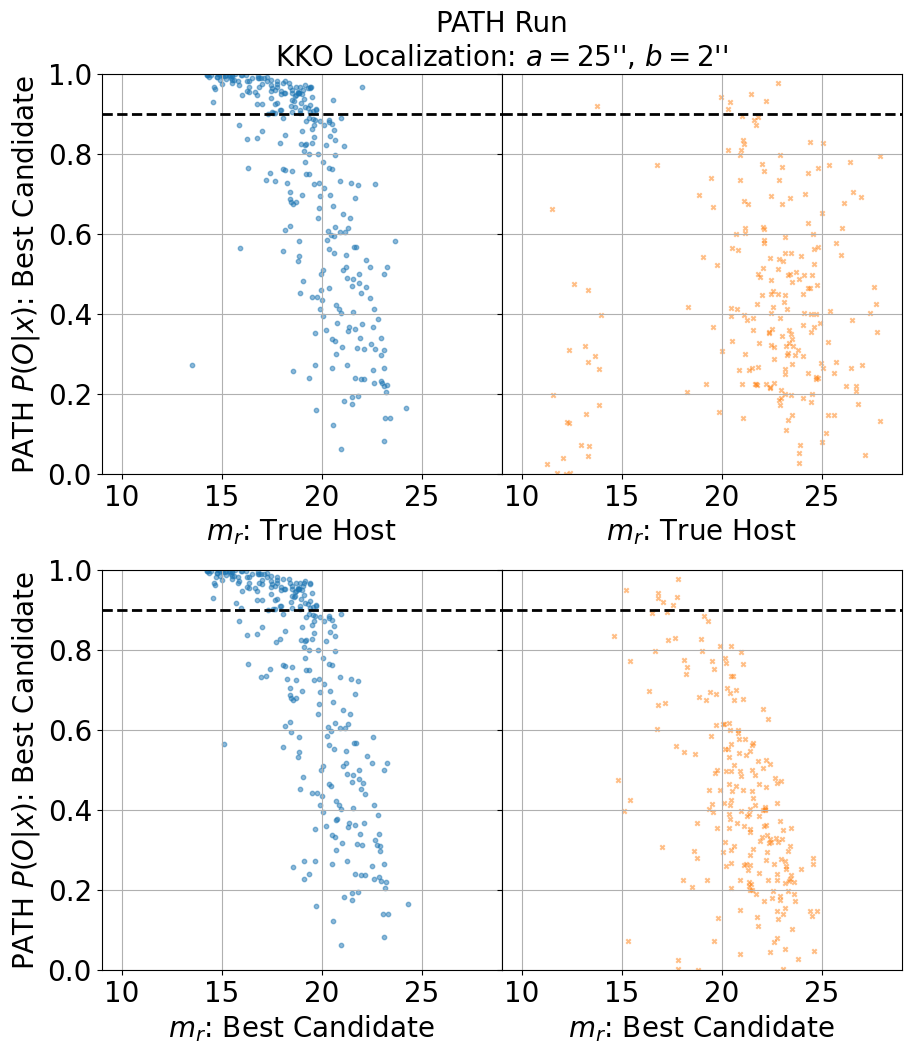

In [18]:
# Make a plot of true galaxy magnitude vs best candidate P(O|x)
# Split it by correct vs incorrect associations
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig = plt.figure(figsize=(8,8))

P_Ox_thresh = 0.9
localization = (25., 2., 12.)  # (a, b, PA) in arcsec, arcsec, degrees
correct_associations = digest[digest['correct_association']]
incorrect_associations = digest[~digest['correct_association']]

# (left, bottom, width, height)
sep_h = 0.12
sep_w = 0.
correct_bestcand_ax = (0, 0., 0.5, 0.5)
incorrect_bestcand_ax = (0.5+sep_w, 0., 0.5, 0.5)
correct_truehost_ax = (0, 0.5+sep_h, 0.5, 0.5)
incorrect_truehost_ax = (0.5+sep_w, 0.5+sep_h, 0.5, 0.5)

ax = plt.axes(correct_bestcand_ax)
plt.scatter(correct_associations['mag_cand'], correct_associations['P_Ox'], color=cycle[0], marker='o', s=10, alpha=0.5, label='Correct Association')
plt.axhline(y=P_Ox_thresh, lw=2, color='black', linestyle='dashed')
plt.xlabel(r'$m_r$: Best Candidate')
plt.ylabel(r'PATH $P(O|x)$: Best Candidate')
plt.grid(zorder=20)
plt.ylim([0,1])
plt.xlim([9,29])

ax = plt.axes(incorrect_bestcand_ax)
plt.scatter(incorrect_associations['mag_cand'], incorrect_associations['P_Ox'], color=cycle[1], marker='x', s=10, alpha=0.5, label='Incorrect Association')
plt.axhline(y=P_Ox_thresh, lw=2, color='black', linestyle='dashed')
plt.xlabel(r'$m_r$: Best Candidate')
ax.set_yticklabels([])
plt.grid(zorder=20)
plt.ylim([0,1])
plt.xlim([9,29])

ax = plt.axes(correct_truehost_ax)
plt.scatter(correct_associations['mag_host'], correct_associations['P_Ox'], color=cycle[0], marker='o', s=10, alpha=0.5, label='Correct Association')
plt.axhline(y=P_Ox_thresh, lw=2, color='black', linestyle='dashed')
plt.xlabel(r'$m_r$: True Host')
plt.ylabel(r'PATH $P(O|x)$: Best Candidate')
plt.grid(zorder=20)
plt.ylim([0,1])
plt.xlim([9,29])

ax = plt.axes(incorrect_truehost_ax)
plt.scatter(incorrect_associations['mag_host'], incorrect_associations['P_Ox'], color=cycle[1], marker='x', s=10, alpha=0.5, label='Incorrect Association')
plt.axhline(y=P_Ox_thresh, lw=2, color='black', linestyle='dashed')
plt.xlabel(r'$m_r$: True Host')
ax.set_yticklabels([])
plt.grid(zorder=20)
plt.ylim([0,1])
plt.xlim([9,29])

plt.suptitle(
    f"PATH Run\n" + r"KKO Localization: $a=$" + "{0:d}'', ".format(int(localization[0])) + r"$b=$" + "{0:d}''".format(int(localization[1])),
    y=1.2, fontsize=20
)

### Magnitude Bias

(11.0, 28.0)

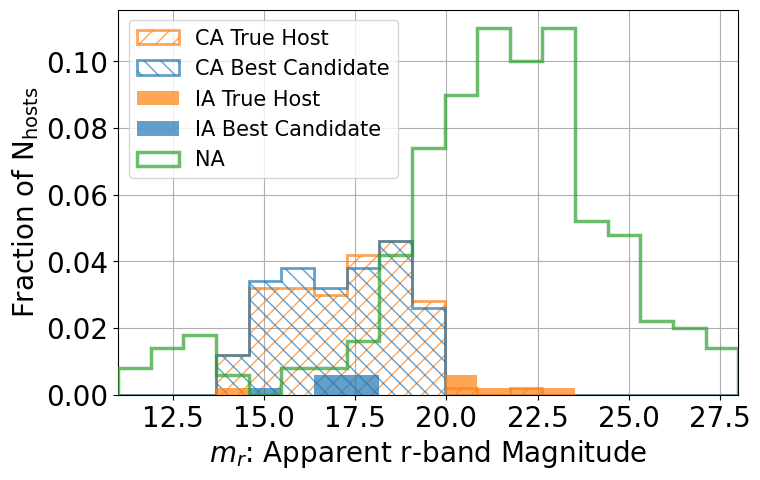

In [19]:
fig = plt.figure(figsize=(8,5))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

correct_mask = digest['correct_association'] & (digest['P_Ox'] > P_Ox_thresh)
incorrect_mask = ~digest['correct_association'] & (digest['P_Ox'] > P_Ox_thresh)
nonassociation_mask = digest['P_Ox'] < P_Ox_thresh
N_frbs = float(len(digest))

correct_associations = digest[correct_mask]
incorrect_associations = digest[incorrect_mask]
nonassociations = digest[nonassociation_mask]

bins = np.linspace(11, 28, 20)

# Plot correct associations
weights = np.ones_like(correct_associations['mag_host']) / N_frbs
_, _, _ = plt.hist(correct_associations['mag_host'], density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[1], alpha=0.7, bins=bins, zorder=5, hatch='//', fill='False', histtype='step', label='CA True Host')
plt.hist(correct_associations['mag_cand'], density=False, weights=weights, facecolor='None', lw=2, edgecolor=cycle[0], alpha=0.7, bins=bins, zorder=5, hatch='\\\\', histtype='step', label='CA Best Candidate')

# Plot incorrect associations
weights = np.ones_like(incorrect_associations['mag_host']) / N_frbs
_, _, _ = plt.hist(incorrect_associations['mag_host'], density=False, weights=weights,  color=cycle[1], alpha=0.7, bins=bins, zorder=5, label='IA True Host')
plt.hist(incorrect_associations['mag_cand'], density=False, weights=weights,  color=cycle[0], alpha=0.7, bins=bins, zorder=5, label='IA Best Candidate')

# Plot non-associations
weights = np.ones_like(nonassociations['mag_host']) / N_frbs
_, bins, _ = plt.hist(nonassociations['mag_host'], density=False, weights=weights, facecolor='None', lw=2.5, edgecolor=cycle[2], alpha=0.7, bins=bins, zorder=5, histtype='step', label='NA')

plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.ylabel(r'Fraction of N$_{\rm hosts}$')
plt.legend(fontsize=15)
plt.grid(zorder=1)
plt.xlim([11,28])

### Offset Bias

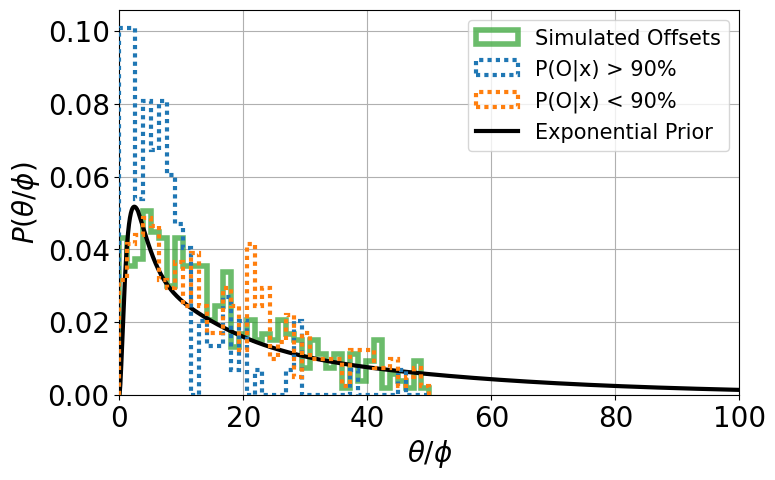

In [23]:
fig = plt.figure(figsize=(8,5))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
lw = 4

# Calculate PATH prior convolved with localization
localization = (25., 2., 12.)  # (a, b, PA) in arcsec, arcsec, degrees
theta_phi = np.arange(0, 100, 0.05)
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}
# Convolved prior for the localization region
theta_phi_conv, prior_conv = sim_utils.stack_convolved_prior(theta_phi, theta_prior, digest[:100], phi_col='ang_size_host')

# Set bins and x-axis zoom
theta_max = int(2*np.nanmax([digest['a'],digest['b']]))
theta_max = np.nanmax([theta_max, 6])
bins = np.linspace(0, theta_max, 40)
density = True

# Plot the true simulated offset distribution
_ = plt.hist(digest['sep_host_loc_norm'], bins=bins, density=density, lw=lw, edgecolor=cycle[2], fill=False, histtype='step', alpha=0.7, label='Simulated Offsets')

# Plot distribution for P(O|x) > 90%
mask = (digest['P_Ox'] > 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[0], alpha=1., label='P(O|x) > 90%', zorder=30) # hatch='//', 

# # Plot distribution for P(O|x) < 90%
mask = (digest['P_Ox'] < 0.9)
_ = plt.hist(digest['sep_best_loc_norm'][mask], bins=bins, density=density, lw=3, linestyle=(0, (1, 1)), histtype='step', color=cycle[1], alpha=1., label='P(O|x) < 90%', zorder=30) # hatch='\\\\',

# Plot the prior
plt.plot(theta_phi_conv, prior_conv, lw=3, color='xkcd:black', label='Exponential Prior')

plt.xlabel(r'$\theta/\phi$')
plt.ylabel(r'$P(\theta/\phi)$')
plt.legend(fontsize=15)
plt.xlim([0,100])
plt.grid()

### Posterior Calibration

In [25]:
import pandas

def calculate_unseen(hosts:pandas.DataFrame, galaxy_catalog:pandas.DataFrame,
                     mag_limit:float=15., thresh_cross_match:float=2.):
    """
    Determines whether a set of FRB host galaxies (hosts) is "unseen" (not detected
    as a source) in the given galaxy catalog of limited magnitude depths

    Args:
        hosts (pandas.DataFrame): Simulated FRB hosts, must contain columns:
            `mag_host`, `ra_host`, `dec_host`, `ang_size_host`
        galaxy_catalog (pandas.DataFrame): Galaxy catalog of limited depth,
            must contain columns: `ra`, `dec`, `ang_size`
        mag_limit (float): Lower limit to filter hosts catalog. This exists because we
            make cuts in our galaxy_catalog samples mr < 14. Thus, below this threshold,
            a simulated host will artificially not have a matching source in the galaxy_catalog.
        thresh_cross_match (float): A factor that sets the cross-matching threshold
            that determines whether an FRB host is "unseen" or not. Specifically,
            it is a multiple of the galaxy half-light radius.

    Returns:
        pandas.DataFrame: Hosts catalog, but with an `unseen` column indicating
            whether the host is visible in the galaxy catalog
    """
    if mag_limit is not None:
        hosts = hosts[hosts['mag_host'] > mag_limit]
    
    host_coords = SkyCoord(ra=hosts.ra_host.values, dec=hosts.dec_host.values, unit='deg')
    galaxy_catalog_coords = SkyCoord(ra=galaxy_catalog.ra.values, dec=galaxy_catalog.dec.values, unit='deg')

    # Match hosts to galaxy catalog sources, finding the closest source at any distance
    print("Starting cross-matching (will take a minute)...")
    start_write = time.time()
    idx, d2d, _ = match_coordinates_sky(host_coords, galaxy_catalog_coords, nthneighbor=1)
    end_write = time.time()
    print("Cross-matching finished. Time elapsed: {0:.3f} minutes".format((end_write-start_write)/60.))

    # Filter by distance, finding those matching within the angular size of the galaxy
    max_ang_size = thresh_cross_match * np.maximum.reduce([hosts['ang_size_host'], galaxy_catalog.iloc[idx]['ang_size']], axis=0)
    dup = (d2d.arcsec <  max_ang_size)
    # galaxy_catalog_keep = galaxy_catalog.iloc[idx[dup]]

    # Add "unseen" status to hosts DataFrame
    unseen = np.full(len(hosts), True)
    unseen[dup] = False
    hosts['unseen'] = unseen
    
    return hosts

In [26]:
# First, load in the pre-queried galaxy catalog
fn = 'catalog_dudxmmlss_hecate_DECaL.parquet'
galaxy_catalog_fn = Path(os.getenv('FRB_APATH')) / fn
if galaxy_catalog_fn.exists():
    galaxy_catalog = load_galaxy_catalog(catalog_fn=fn)
else:
    raise FileNotFoundError(f"The file {fn} does not exist")

Loading real galaxy catalog from:
  /Users/bandersen/Documents/CHIME/notebooks/path_simulations/catalogs/catalog_dudxmmlss_hecate_DECaL.parquet


In [ ]:
digest_filt = calculate_unseen(digest, galaxy_catalog, thresh_cross_match=2.)

Starting cross-matching (will take a minute)...


In [ ]:
fig = plt.figure(figsize=(12,6))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
sep_w = 0.1
post_POx_ax = (0., 0., 0.5, 0.8)
hist_POx_ax = (0., 0.8, 0.5, 0.2)
post_PUx_ax = (0.5+sep_w, 0., 0.5, 0.8)
hist_PUx_ax = (0.5+sep_w, 0.8, 0.5, 0.2)

# Plot P(O|x) Posteriors
ax = plt.axes(hist_POx_ax)

# Plot histogram
bins = np.linspace(0,1,20)
weights = np.ones_like(digest['P_Ox']) / len(digest)
_ = plt.hist(digest['P_Ox'], bins=bins, weights=weights, density=False, histtype='step', lw=3, color=cycle[1], alpha=0.8)
plt.ylabel('% of FRBs')
plt.xlim([0.,1.])
plt.grid(zorder=20)
ax.set_xticklabels([])

ax = plt.axes(post_POx_ax)

# Jackknife to get errors
N = 20
tp_jn_data = []
for kk in range(N):
    # Remove 1/5 of points
    inds = random.sample(range(len(digest)), int(len(digest)/5))
    digest_jn = digest.iloc[inds]
    
    # Calculate correct association rate vs P(O|x) in each bin
    P_Ox_bin_edges = np.arange(0, 1.2, 0.2)
    tp_fraction = []
    for ii in range(len(P_Ox_bin_edges)-1):
        P_Ox_start_bin = P_Ox_bin_edges[ii]
        P_Ox_end_bin = P_Ox_bin_edges[ii+1]
        in_bin = (digest_jn['P_Ox'] >= P_Ox_start_bin) & (digest_jn['P_Ox'] <= P_Ox_end_bin)
        digest_in_bin = digest_jn[in_bin]
        digest_tp = digest_in_bin[digest_in_bin['correct_association']]
        if len(digest_in_bin) in range(5):
            tp_frac = np.nan
        else:
            tp_frac = len(digest_tp) / len(digest_in_bin)
        tp_fraction.append(tp_frac)
    P_Ox_bin_centers = (P_Ox_bin_edges[:-1] + P_Ox_bin_edges[1:]) / 2.
    tp_jn_data.append(tp_fraction)
# Plot points    
plt.errorbar(
    P_Ox_bin_centers, np.nanmean(tp_jn_data, axis=0), yerr=np.nanstd(tp_jn_data, axis=0), 
    capsize=5, elinewidth=2, markersize=15, mew=3, color=cycle[1], marker='+', 
    linestyle="None", alpha=0.8, label='CK',
) 
plt.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), lw=2, color='black')
plt.xlabel('P(O|x)')
plt.ylabel('Correct Association Fraction')
plt.legend(fontsize=15)
plt.grid(zorder=20)
plt.ylim([0.,1.])
plt.xlim([0.,1.])


# Plot P(U|x) Posteriors
ax = plt.axes(hist_PUx_ax)

# Plot histogram
bins = np.linspace(0,1,20)
weights = np.ones_like(digest_filt['P_Ux']) / len(digest_filt)
_ = plt.hist(digest_filt['P_Ux'], bins=bins, weights=weights, density=False, histtype='step', lw=3, color=cycle[1], alpha=0.8)
plt.ylabel('% of FRBs')
plt.xlim([0.,1.])
plt.grid(zorder=20)
ax.set_xticklabels([])

ax = plt.axes(post_PUx_ax)

# Jackknife to get errors
N = 20
unseen_jn_data = []
for kk in range(N):
    # Remove 1/5 of points
    inds = random.sample(range(len(digest_filt)), int(len(digest_filt)/5))
    digest_jn = digest_filt.iloc[inds]
    
    # Calculate correct association rate vs P(U|x) in each bin
    P_Ux_bin_edges = np.arange(0, 1.2, 0.2)
    unseen_fraction = []
    for ii in range(len(P_Ux_bin_edges)-1):
        P_Ux_start_bin = P_Ux_bin_edges[ii]
        P_Ux_end_bin = P_Ux_bin_edges[ii+1]
        in_bin = (digest_jn['P_Ux'] >= P_Ux_start_bin) & (digest_jn['P_Ux'] <= P_Ux_end_bin)
        digest_in_bin = digest_jn[in_bin]
        digest_unseen = digest_in_bin[digest_in_bin['unseen']]
        if len(digest_in_bin) in range(5):
            unseen_frac = np.nan
        else:
            unseen_frac = len(digest_unseen) / len(digest_in_bin)
        unseen_fraction.append(unseen_frac)
    P_Ux_bin_centers = (P_Ux_bin_edges[:-1] + P_Ux_bin_edges[1:]) / 2.
    unseen_jn_data.append(unseen_fraction)
# Plot points    
plt.errorbar(
    P_Ux_bin_centers, np.nanmean(unseen_jn_data, axis=0), yerr=np.nanstd(unseen_jn_data, axis=0), 
    capsize=5, elinewidth=2, markersize=15, mew=3, color=cycle[1], marker='+', 
    linestyle="None", alpha=0.8, label='CK',
) 
plt.plot(np.arange(0,1.1,0.1), np.arange(0,1.1,0.1), lw=2, color='black')
plt.xlabel('P(U|x)')
plt.ylabel('Unseen Fraction')
plt.legend(fontsize=15)
plt.grid(zorder=20)
plt.ylim([0.,1.])
plt.xlim([0.,1.])